# The fire-extinguisher fund: does a trend sleeve fix a 60/40? 🧯
### Managed futures in a normal portfolio — the ad, the tape, and 2022, in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Bonds_in_disguise%3F: Busted](https://img.shields.io/badge/Bonds_in_disguise%3F-Busted-8b949e?style=flat-square)

After 2022 — the year stocks **and** bonds fell together — a new pitch took over the allocation world: *put 10-20% of your portfolio into a managed-futures fund.* These funds (trend-followers) buy whatever has been rising and short whatever has been falling, across stock indexes, bonds, oil, gold, currencies. The ad says two things: they're **uncorrelated** with everything else you own, and they **pay off in crises** — in 2022 they were up +20-30% while everything else burned.

We've already tested whether trend-following is a great strategy *on its own* — twice ([31-trade-winds](../../31-trade-winds/), [518-time-series-momentum](../../518-time-series-momentum/)) — and both times the answer was **Weak**. This study asks the different, sharper question the industry actually sells: even if it's mediocre alone, does *adding a slice of it* make a normal 60/40 portfolio **better**?

> 📓 **Plain-language layer.** Want the t-stats, bootstraps and robustness grids? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Our long history is a *replication* (a simple 12-month trend rule on 18 futures, with costs and the real ETF's 0.85%/yr fee charged) — the live ETFs (DBMF, KMLM) only exist since 2019, and we cross-check on them. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from managed_futures_allocation import data, strategy as st

SLEEVE, FEE, COST_BPS = 0.15, 0.0085, 5.0
HAVE_REAL = data.have_real()
if HAVE_REAL:
    FUT = data.load_futures()
    FM = data.drop_partial_last_month(data.monthly_from_daily_returns(FUT), FUT.index.max())
    ETFS = data.load_etfs()
    TR = data.monthly_total_returns(ETFS[["SPY", "VBMFX", "DBMF", "KMLM"]])
    RF = data.monthly_rf(ETFS["^IRX"])
    BOOK = st.tsmom_book(FM, lookback=12, cost_bps=COST_BPS)
    P6040_FULL = st.portfolio_6040(TR["SPY"], TR["VBMFX"])
    IDX = P6040_FULL.index.intersection(BOOK["net"].index).intersection(RF.dropna().index)
    P6040, RF_I = P6040_FULL.loc[IDX], RF.loc[IDX]
    E6040 = P6040 - RF_I
    MF_NET = BOOK["net"].loc[IDX]           # futures excess, net of turnover costs
    MF_FUNDED = RF_I + MF_NET               # cash-collateralised sleeve (gross of ETF fee)
    BLEND = st.blend_returns(P6040, MF_NET, RF_I, SLEEVE, FEE)
else:
    FUT = FM = ETFS = TR = RF = BOOK = None
    P6040 = RF_I = E6040 = MF_NET = MF_FUNDED = BLEND = None
print("real caches present:", HAVE_REAL,
      "| joint months:", (0 if P6040 is None else len(P6040)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-07-03', 'joint_start': '2001-09-30', 'joint_end': '2026-05-31', 'n_months': 297, 'fingerprint': '2f0e9858dde3', 'fut_fp': 'b1cdf7bc6129', 'book': {'sharpe': 0.407, 'nw_t': 2.05, 'vol': 18.4, 'maxdd': -29.6, 'cagr': 7.73, 'lev': 3.71, 'turn': 1.12}, 'corr_6040': (-0.054, -0.167, 0.06, 297), 'corr_stocks': (-0.053, -0.166, 0.061, 297), 'corr_bonds': (-0.021, -0.135, 0.093, 297), 'corr_dbmf': (-0.212, -0.408, 0.002, 84), 'corr_kmlm': (-0.432, -0.611, -0.21, 65), 'corr_dbmf_book': (0.682, 0.547, 0.783, 84), 'p6040': {'cagr': 7.52, 'vol': 9.37, 'sharpe': 0.643, 'maxdd': -32.4, 'mar': 0.232}, 'blend': {'cagr': 7.72, 'vol': 8.29, 'sharpe': 0.738, 'maxdd': -23.4, 'mar': 0.33}, 'alpha': {'ann': 8.13, 't': 2.1, 'beta': -0.107, 'r2': 0.3}, 'dsharpe': {'obs': 0.095, 'lo': -0.064, 'hi': 0.242, 'p': 0.119, 'draws': 5000, 'block': 6}, 'sleeves': [(10, 0.713, -26.5, 0.07, -0.031, 0.162, 0.08), (15, 0.738, -23.4, 0.095, -0.064, 0.242, 0.119), (20, 0.753, -20.2, 0.11, -0.111, 0.317, 0.164)], 'costs': [(2.0, 8.52, 2.2), (5.0, 8.13, 2.1), (10.0, 7.46, 1.92)], 'lookbacks': [(9, 0.209, 1.35, 0.045), (12, 0.407, 2.1, 0.095), (15, 0.352, 1.67, 0.06)], 'nw_lags': [(3, 2.06), (6, 2.1), (12, 2.25)], 'subperiods': [('2001-09 - 2008-12', -0.08, 0.17, 0.257, 0.69), ('2009-01 - 2019-12', 1.2, 1.09, -0.107, 0.1), ('2020-01 - 2026-05', 0.63, 0.78, 0.147, 0.55)], 'y2022': {'spy': -18.18, 'bonds': -13.24, 'p6040': -15.91, 'sleeve': 33.13, 'blend': -9.02, 'dbmf': 21.6, 'kmlm': 24.24, 'contrib': 5.0}, 'bonds_axis': {'corr': -0.021, 'beta': -0.093, 'r2': 0.0, 'p4555_sharpe': 0.664, 'p4555_dd': -24.1, 'p4555_2022': -15.15}, 'live': {'start': '2019-07-31', 'end': '2026-06-30', 'n': 84, 'dbmf_cagr': 8.85, 'dbmf_vol': 11.4, 'dbmf_sharpe': 0.562, 'dbmf_dd': -17.3, 's6040': 0.671, 'dd6040': -20.1, 'sblend': 0.79, 'ddblend': -13.5, 'ds': 0.119, 'lo': -0.048, 'hi': 0.279, 'p': 0.09}, 'placebo': {'seeds': 24, 'book_sharpe': -0.23, 'book_sd': 0.197, 'ds': -0.0772, 'ds_sd': 0.0448}, 'syn': [(0.0, -0.026, -0.106, 0.062, 0.697, 0.0), (0.8, 0.156, 0.077, 0.246, 0.0, 4.45)]}


real caches present: True | joint months: 297


## The answer first

| Question | Answer |
|---|---|
| Is it really uncorrelated with a 60/40? | **Yes — genuinely.** Correlation ≈ **-0.05** over 25 years; the live funds are even *negative* (they zig when your portfolio zags). |
| Did it deliver in 2022? | **Yes.** Our sleeve made **+33%** (the live funds +22 to +24%) while the 60/40 lost **-16%**. The blend lost only **-9%**. |
| So does the sleeve make the portfolio better? | **Probably — but the tape can't prove it.** Sharpe 0.64 → 0.74 and the worst drawdown shrinks by 9 points, but the improvement is within statistical noise, and it spent **2009-2019 quietly costing you**. |
| Is it secretly just a bond fund? | **No — busted.** Zero correlation to bonds, and in 2022 it was *short* bonds and profited while bonds lost 13%. |

## Two and a half decades, side by side

Take a plain 60/40 (60% S&P 500, 40% total-bond, rebalanced monthly). Now carve out 15% and give it to the trend sleeve (paying the real fund's 0.85%/yr fee). Same money, two histories:

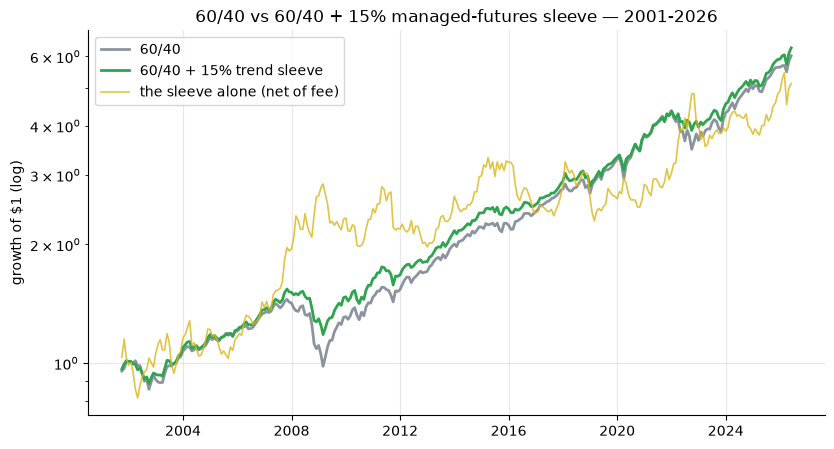

60/40: 7.52%/yr, worst fall -32.4%
blend: 7.72%/yr, worst fall -23.4%


In [2]:
if HAVE_REAL:
    w60 = (1 + P6040).cumprod(); wbl = (1 + BLEND).cumprod()
    wmf = (1 + MF_FUNDED - FEE/12).cumprod()
    fig, ax = plt.subplots()
    ax.plot(w60.index, w60, color=GREY, lw=2, label='60/40')
    ax.plot(wbl.index, wbl, color=GREEN, lw=2, label='60/40 + 15% trend sleeve')
    ax.plot(wmf.index, wmf, color=AMBER, lw=1.2, alpha=.8, label='the sleeve alone (net of fee)')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
    ax.set_title('60/40 vs 60/40 + 15% managed-futures sleeve — 2001-2026')
    ax.legend()
    plt.show()
    print(f"60/40: {R['p6040']['cagr']}%/yr, worst fall {R['p6040']['maxdd']}%")
    print(f"blend: {R['blend']['cagr']}%/yr, worst fall {R['blend']['maxdd']}%")
else:
    print('caches missing — see docs/results.md for the frozen numbers')


Similar destination, **smoother road**: the blend ends slightly *ahead* (7.72% vs 7.52%/yr) with a whole point and a half less volatility, and its worst peak-to-trough fall is **−23%** instead of **−32%**. That combination — same return, less pain — is what "diversification" is supposed to buy.

> 🔬 **For the quants:** the Sharpe goes 0.643 → 0.738; whether that +0.095 is *statistically certifiable* is the whole fight in notebook 02 (spoiler: it is not).

## "Uncorrelated" — the half of the ad that is simply true

Each dot below is one month: how the 60/40 did (x-axis) versus how the sleeve did (y-axis). If the sleeve were a closet stock fund the cloud would slope up; a closet bond fund, same thing. It doesn't slope at all:

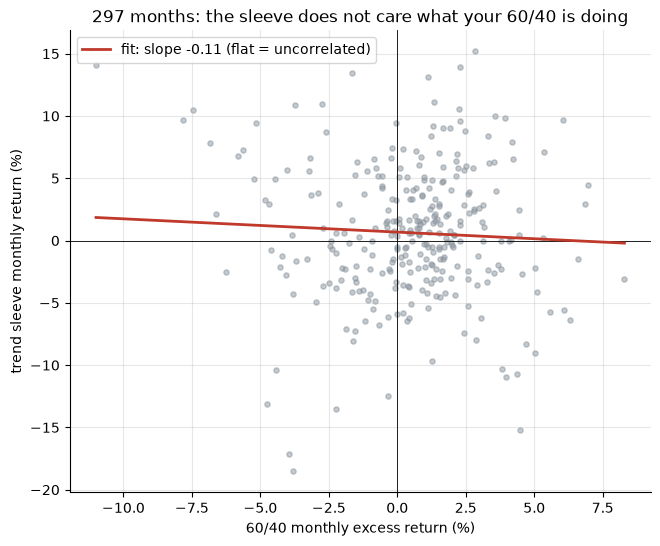

correlation = -0.054  (95% CI [-0.167, +0.060])


In [3]:
if HAVE_REAL:
    fig, ax = plt.subplots(figsize=(7.5, 6))
    ax.scatter(E6040*100, MF_NET*100, s=14, alpha=.5, color=GREY)
    ax.axhline(0, color='k', lw=.6); ax.axvline(0, color='k', lw=.6)
    b = np.polyfit(E6040, MF_NET, 1)
    xs = np.linspace(E6040.min(), E6040.max(), 50)
    ax.plot(xs*100, (b[0]*xs+b[1])*100, color=RED, lw=2,
            label=f'fit: slope {b[0]:+.2f} (flat = uncorrelated)')
    ax.set_xlabel('60/40 monthly excess return (%)')
    ax.set_ylabel('trend sleeve monthly return (%)')
    ax.set_title('297 months: the sleeve does not care what your 60/40 is doing')
    ax.legend()
    plt.show()
    c = st.corr_ci(MF_NET, E6040)
    print(f"correlation = {c['r']:+.3f}  (95% CI [{c['lo']:+.3f}, {c['hi']:+.3f}])")


Correlation **-0.05**, statistically indistinguishable from zero — and the *live* funds since 2019 are actually **negative** (DBMF -0.21, KMLM -0.43). Almost nothing you can buy with one ticker has that property. This half of the pitch is **real**.

## 2022 — the year the fire actually happened

The whole point of insurance is the one year you need it. In 2022 the Fed hiked, and for the first time in 40 years stocks and bonds fell **together** — the 60/40's diversification failed exactly when it was needed. The trend sleeve was short bonds, short stocks, long the dollar and long energy... by *following the trend down*:

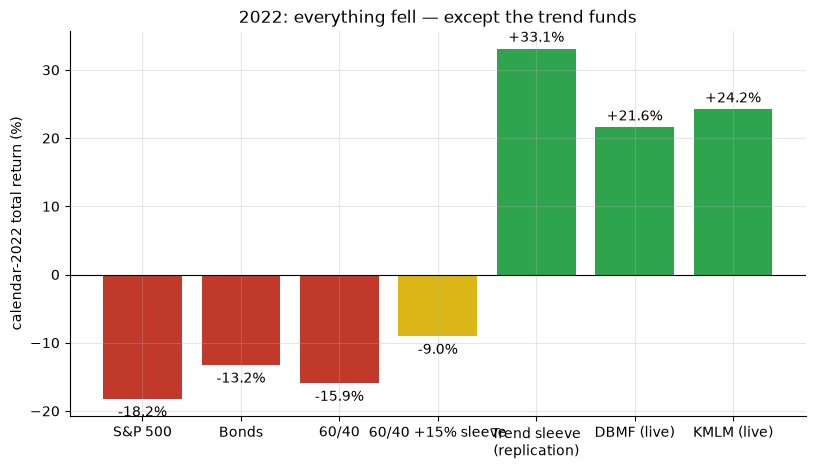

sleeve contribution to the blend in 2022: about +5 points


In [4]:
y = R['y2022']
names = ['S&P 500', 'Bonds', '60/40', '60/40 +15% sleeve', 'Trend sleeve\n(replication)',
         'DBMF (live)', 'KMLM (live)']
vals = [y['spy'], y['bonds'], y['p6040'], y['blend'], y['sleeve'], y['dbmf'], y['kmlm']]
cols = [RED, RED, RED, AMBER, GREEN, GREEN, GREEN]
fig, ax = plt.subplots()
bars = ax.bar(names, vals, color=cols)
ax.axhline(0, color='k', lw=.8)
for b_, v in zip(bars, vals):
    ax.text(b_.get_x()+b_.get_width()/2, v + (1 if v > 0 else -2.6),
            f'{v:+.1f}%', ha='center', fontsize=10)
ax.set_ylabel('calendar-2022 total return (%)')
ax.set_title('2022: everything fell — except the trend funds')
plt.show()
print(f"sleeve contribution to the blend in 2022: about +{y['contrib']:.0f} points")


The blend lost **−9%** instead of **−16%**. One year proves nothing statistically — but it is exactly the payoff the product was sold on, and it happened in the live funds too, net of fees. *(Note our replication's +33% is flattering vs the live funds' +22-24% — real-world slippage is real.)*

## The fine print: the decade the insurance just cost money

Here's the part the ads skip. Split the 25 years into three regimes:

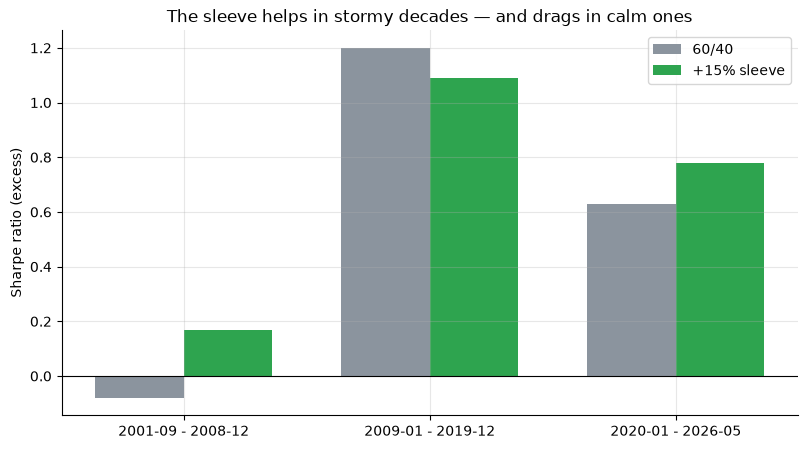

2001-09 - 2008-12: 60/40 Sharpe -0.08 -> blend +0.17  (change +0.257)
2009-01 - 2019-12: 60/40 Sharpe +1.20 -> blend +1.09  (change -0.107)
2020-01 - 2026-05: 60/40 Sharpe +0.63 -> blend +0.78  (change +0.147)


In [5]:
labels = [s[0] for s in R['subperiods']]
s60 = [s[1] for s in R['subperiods']]; sbl = [s[2] for s in R['subperiods']]
x = np.arange(3); w = 0.36
fig, ax = plt.subplots()
ax.bar(x-w/2, s60, w, color=GREY, label='60/40')
ax.bar(x+w/2, sbl, w, color=GREEN, label='+15% sleeve')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Sharpe ratio (excess)')
ax.set_title('The sleeve helps in stormy decades — and drags in calm ones')
ax.axhline(0, color='k', lw=.8); ax.legend()
plt.show()
for lab, a, b_, d, _ in R['subperiods']:
    print(f'{lab}: 60/40 Sharpe {a:+.2f} -> blend {b_:+.2f}  (change {d:+.3f})')


In 2001-2008 (dot-com bust, GFC) and 2020-2026 (Covid, the 2022 inflation shock) the sleeve earned its keep. But through the **entire 2009-2019 bull decade** it was a drag — eleven years of paying for an extinguisher while nothing caught fire. That's not a flaw exactly — it's what insurance *is* — but it's why the improvement never rises out of the statistical noise, and why most investors who bought trend funds in 2010 had sold them by 2019, just in time to miss 2022.

## The verdict, in plain words

- **The "uncorrelated" claim is true.** ≈ -0.05 to a 60/40 over 25 years; the live funds are negative. Rare and genuine.
- **It is not a bond fund in a costume.** Zero correlation to bonds — and in 2022 it made +33% *because* it was short the bonds that were falling. Putting the same 15% into more bonds instead would have made 2022 **worse** (−15% vs −9%).
- **The improvement is real-looking but unprovable.** Sharpe 0.64 → 0.74, worst fall −32% → −23% — but 25 years of data is not enough to certify a +0.10 Sharpe from a strategy this streaky, and the quants' confidence interval firmly includes zero.
- **You can actually buy it** (DBMF/KMLM, one ticket, ~0.85%/yr) — cheap access to a benefit the tape can't guarantee. **Signal: Mixed. Tradability: Fragile. Bonds-in-disguise: Busted.**

> 📓 Full statistics, robustness grids and the honest fine print: **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** · frozen numbers: [`docs/results.md`](../docs/results.md) (fingerprint `2f0e9858dde3`).

*Research & education, not investment advice.*